In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import nibabel as nib
from pathlib import Path

In [2]:
segmentations_folder_path = Path(r"/home/chest_ct/code/data/segmentations/segmentations")

files = [
    f for f in os.listdir(segmentations_folder_path)
    if os.path.isfile(os.path.join(segmentations_folder_path, f))
]

# Exploratory Data Analysis

## CT-RATE

In [3]:
train_labels = pd.read_csv(r"/home/chest_ct/code/data/ct-rate/train_labels.csv")
valid_labels = pd.read_csv(r"/home/chest_ct/code/data/ct-rate/valid_labels.csv")
print("No of train labels:", train_labels["VolumeName"].nunique())
print("No of valid labels:", valid_labels["VolumeName"].nunique())
print("Total labels:", train_labels["VolumeName"].nunique() + valid_labels["VolumeName"].nunique())

No of train labels: 47149
No of valid labels: 3039
Total labels: 50188


In [4]:
import os

data_volumes_folder_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"

nii_gz_files = []

for root, dirs, files in os.walk(data_volumes_folder_path):
    for file in files:
        if file.endswith(".nii.gz"):
            nii_gz_files.append(os.path.join(root, file))

nii_gz_files

['/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_12342/train_12342_a/train_12342_a_1.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_5368/train_5368_a/train_5368_a_1.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_34/train_34_a/train_34_a_2.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_917/train_917_a/train_917_a_2.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_7900/train_7900_b/train_7900_b_1.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_7656/train_7656_a/train_7656_a_2.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_10380/train_10380_a/train_10380_a_2.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_7331/train_7331_a/train_7331_a_2.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_11296/train_11296_a/train_11296_a_1.nii.gz',
 '/home/chest_ct/code/data/d

In [5]:
train_labels.head()

,VolumeName,Medical material,Arterial wall calcification,Cardiomegaly,Pericardial effusion,Coronary artery wall calcification,Hiatal hernia,Lymphadenopathy,Emphysema,Atelectasis,Lung nodule,Lung opacity,Pulmonary fibrotic sequela,Pleural effusion,Mosaic attenuation pattern,Peribronchial thickening,Consolidation,Bronchiectasis,Interlobular septal thickening
0,train_1_a_1.nii.gz,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0
1,train_1_a_2.nii.gz,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0
2,train_2_a_1.nii.gz,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0
3,train_2_a_2.nii.gz,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0
4,train_3_a_1.nii.gz,0,1,1,0,1,0,1,0,0,1,1,1,0,0,1,0,1,0


In [6]:
# Count of positive cases per label
label_counts = train_labels.drop("VolumeName", axis=1).sum().sort_values(ascending=False)
print(label_counts)

Lung nodule                           21382
Lung opacity                          17420
Arterial wall calcification           13377
Pulmonary fibrotic sequela            12589
Atelectasis                           12263
Lymphadenopathy                       12221
Coronary artery wall calcification    12025
Emphysema                              9122
Consolidation                          8319
Hiatal hernia                          6751
Medical material                       5818
Pleural effusion                       5705
Cardiomegaly                           5308
Peribronchial thickening               4973
Bronchiectasis                         4732
Interlobular septal thickening         3745
Mosaic attenuation pattern             3638
Pericardial effusion                   3412
dtype: int64


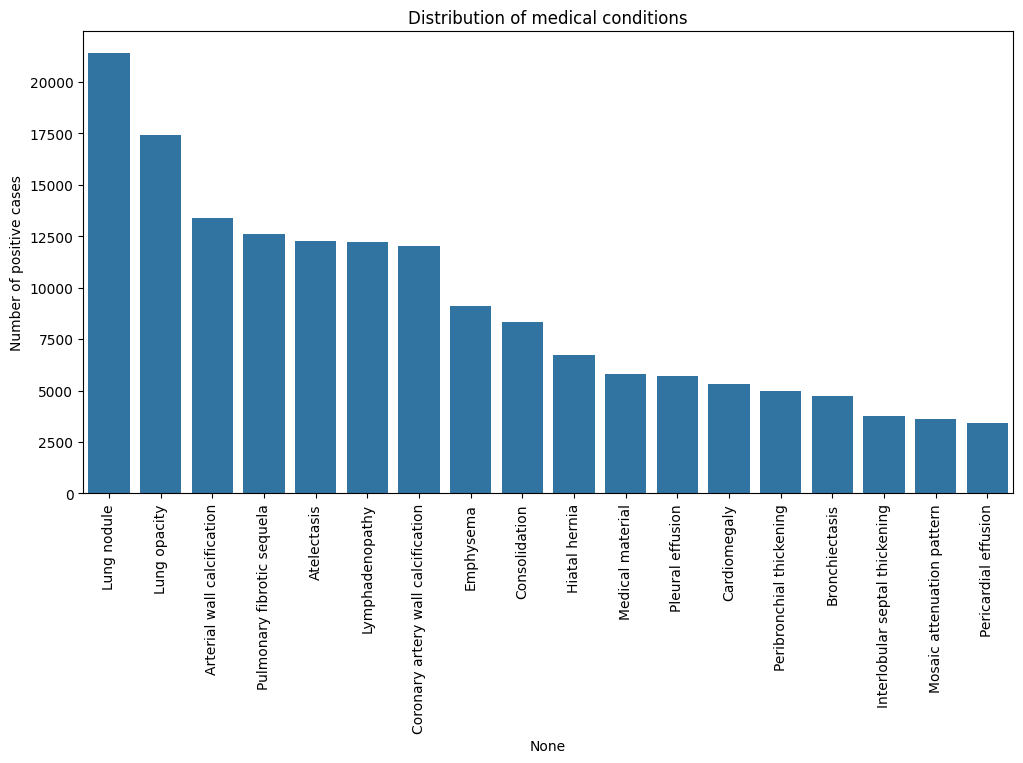

In [7]:
plt.figure(figsize=(12,6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Number of positive cases")
plt.title("Distribution of medical conditions")
plt.show()

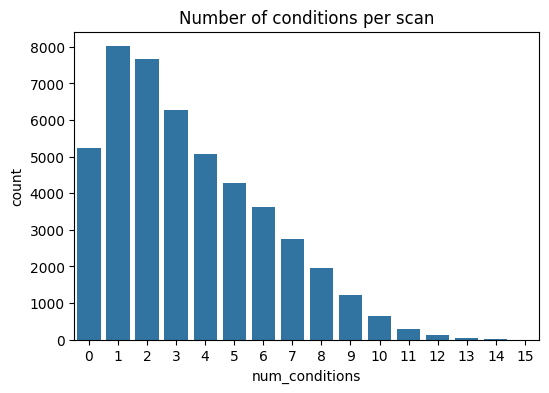

In [8]:
# Count of positive labels per scan
train_labels['num_conditions'] = train_labels.drop("VolumeName", axis=1).sum(axis=1)

plt.figure(figsize=(6,4))
sns.countplot(x='num_conditions', data=train_labels)
plt.title("Number of conditions per scan")
plt.show()

train_labels = train_labels.drop("num_conditions", axis=1)

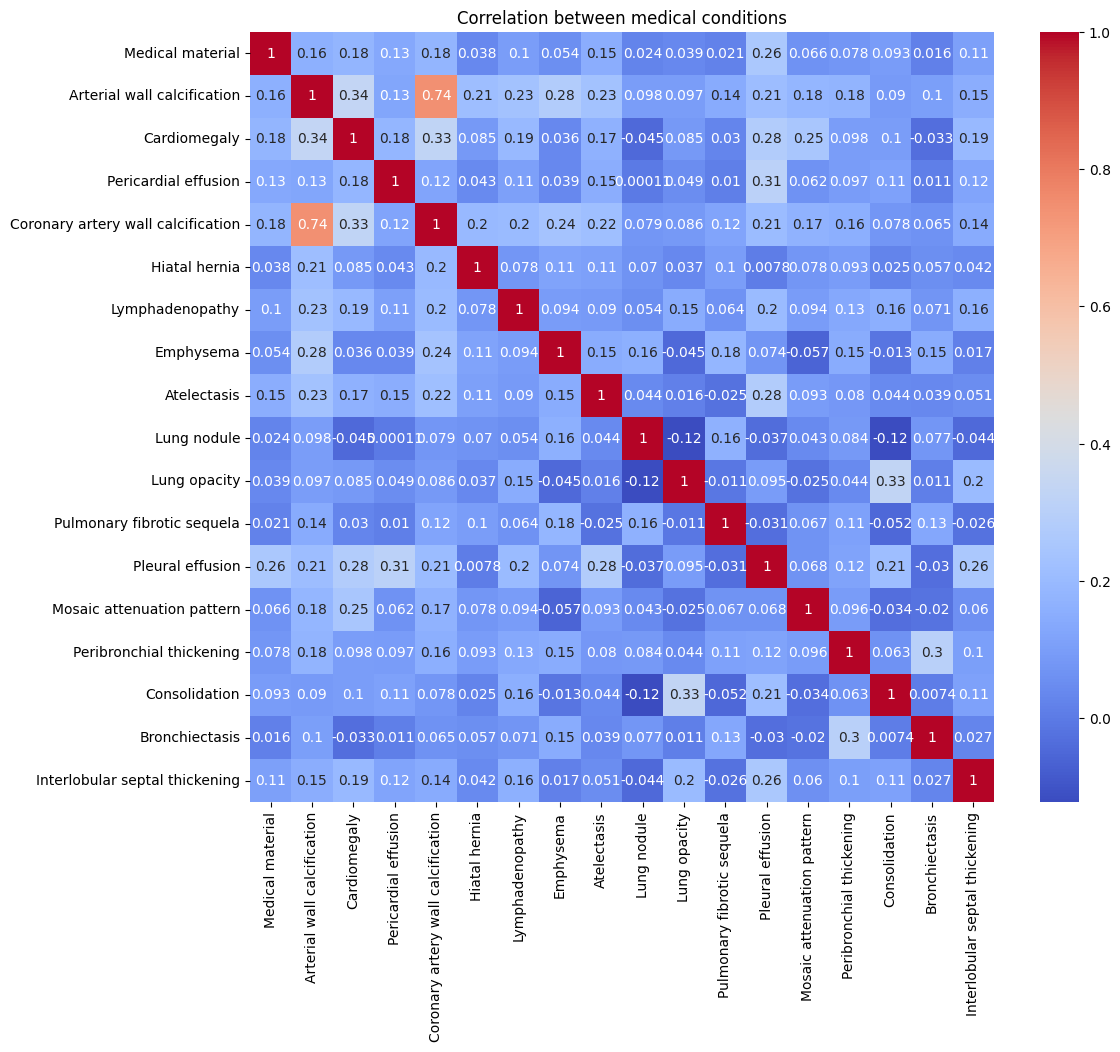

In [9]:
corr_matrix = train_labels.drop("VolumeName", axis=1).corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation between medical conditions")
plt.show()

In [10]:
# Unstack into pairs
corr_pairs = corr_matrix.unstack()

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Remove duplicate pairs
corr_pairs = corr_pairs.to_frame('correlation')
corr_pairs['sorted_index'] = corr_pairs.index.map(lambda x: tuple(sorted(x)))
corr_pairs = corr_pairs.groupby('sorted_index')['correlation'].first()

# Sort by absolute correlation
corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Display top correlations
print(corr_pairs.head(10))

sorted_index
(Arterial wall calcification, Coronary artery wall calcification)    0.744473
(Arterial wall calcification, Cardiomegaly)                          0.338042
(Consolidation, Lung opacity)                                        0.329736
(Cardiomegaly, Coronary artery wall calcification)                   0.327012
(Pericardial effusion, Pleural effusion)                             0.311286
(Bronchiectasis, Peribronchial thickening)                           0.301695
(Atelectasis, Pleural effusion)                                      0.280365
(Cardiomegaly, Pleural effusion)                                     0.278330
(Arterial wall calcification, Emphysema)                             0.277502
(Medical material, Pleural effusion)                                 0.259041
Name: correlation, dtype: float64


In [11]:
# check how many scans have Arterial wall calcification but not Coronary artery wall calcification
arterial_only = train_labels[
    (train_labels["Arterial wall calcification"] == 1) &
    (train_labels["Coronary artery wall calcification"] == 0)
]
print(f"Scans with Arterial wall calcification only: {len(arterial_only)}")

# check how many scans have Coronary artery wall calcification but not Arterial wall calcification
coronary_only = train_labels[
    (train_labels["Arterial wall calcification"] == 0) &
    (train_labels["Coronary artery wall calcification"] == 1)
]
print(f"Scans with Coronary artery wall calcification only: {len(coronary_only)}")

# check how many scans have both Arterial and Coronary artery wall calcifications
both = train_labels[
    (train_labels["Arterial wall calcification"] == 1) &
    (train_labels["Coronary artery wall calcification"] == 1)
]
print(f"Scans with both Arterial and Coronary artery wall calcifications: {len(both)}")

Scans with Arterial wall calcification only: 3068
Scans with Coronary artery wall calcification only: 1716
Scans with both Arterial and Coronary artery wall calcifications: 10309


In [12]:
#find list of normal scans with no positive labels
normal_scans = train_labels[
    (train_labels.drop("VolumeName", axis=1).sum(axis=1) == 0)
]
print(f"Number of normal scans with no positive labels: {len(normal_scans)}")

Number of normal scans with no positive labels: 5226


In [13]:
from pathlib import Path

data_volumes_folder_path = Path("/home/chest_ct/code/data/data_volumes/dataset/train_fixed")

# Get all .nii.gz filenames (without full path)
nii_files = [f.name for f in data_volumes_folder_path.rglob("*.nii.gz")]

# Convert dataframe column to a set for fast lookup
normal_scan_names = set(normal_scans["VolumeName"])

# Find matches
matching_files = [f for f in nii_files if f in normal_scan_names]

print("Total .nii.gz files:", len(nii_files))
print("Files found in normal_scans:", len(matching_files))

Total .nii.gz files: 2465
Files found in normal_scans: 348


In [14]:
matching_files

['train_12342_a_1.nii.gz',
 'train_10990_a_1.nii.gz',
 'train_9664_a_1.nii.gz',
 'train_2863_a_1.nii.gz',
 'train_5462_a_2.nii.gz',
 'train_6311_a_2.nii.gz',
 'train_11126_a_1.nii.gz',
 'train_5837_a_1.nii.gz',
 'train_12578_a_2.nii.gz',
 'train_19388_b_2.nii.gz',
 'train_17490_a_1.nii.gz',
 'train_12074_a_2.nii.gz',
 'train_13236_a_2.nii.gz',
 'train_19503_a_4.nii.gz',
 'train_5023_a_2.nii.gz',
 'train_5102_b_2.nii.gz',
 'train_6321_b_2.nii.gz',
 'train_12594_a_2.nii.gz',
 'train_783_a_2.nii.gz',
 'train_783_a_1.nii.gz',
 'train_5864_b_1.nii.gz',
 'train_12132_a_2.nii.gz',
 'train_19988_a_2.nii.gz',
 'train_5637_a_1.nii.gz',
 'train_3779_a_2.nii.gz',
 'train_2822_a_2.nii.gz',
 'train_5039_a_1.nii.gz',
 'train_3528_a_1.nii.gz',
 'train_3528_a_2.nii.gz',
 'train_8785_a_1.nii.gz',
 'train_4381_a_2.nii.gz',
 'train_1033_a_2.nii.gz',
 'train_10566_a_2.nii.gz',
 'train_7553_a_1.nii.gz',
 'train_7277_a_2.nii.gz',
 'train_6845_a_1.nii.gz',
 'train_6997_a_1.nii.gz',
 'train_18696_a_1.nii.gz',


## RexGroundingCT

In [15]:
with open('/home/chest_ct/code/data/rexgrounding-ct/dataset_3.json', 'r') as file:
    rex_data = json.load(file)

rex_train_df = pd.DataFrame(rex_data["train"])
rex_valid_df = pd.DataFrame(rex_data["val"])
rex_test_df = pd.DataFrame(rex_data["test"])
print("RexGrounding-CT Train set size:", len(rex_train_df))
print("RexGrounding-CT Valid set size:", len(rex_valid_df))
print("RexGrounding-CT Test set size:", len(rex_test_df))
print("Total RexGrounding-CT samples:", len(rex_train_df) + len(rex_valid_df) + len(rex_test_df))

RexGrounding-CT Train set size: 1701
RexGrounding-CT Valid set size: 23
RexGrounding-CT Test set size: 41
Total RexGrounding-CT samples: 1765


In [16]:
rex_categories = {
    "1a": "Bronchial wall thickening",
    "1b": "Bronchiectasis",
    "1c": "Emphysema (including centrilobular, paraseptal, bullous)",
    "1d": "Septal thickening (including interlobular septal thickening, reticulation)",
    "1e": "Micronodules (including centrilobular, tree-in-bud, perilymphatic)",
    "1f": "Other non-focal abnormalities",

    "2a": "Linear (including subsegmental atelectasis, scarring, fibrosis)",
    "2b": "Atelectasis, consolidation",
    "2c": "Groundglass opacity",
    "2d": "Pulmonary nodules/masses",
    "2e": "Pleural effusion or thickening",
    "2f": "Honeycombing",
    "2g": "Pneumothorax",
    "2h": "Other focal abnormalities"
}

In [17]:
from collections import Counter

category_counts = Counter()

for split in ["train", "val", "test"]:
    df = pd.DataFrame(rex_data[split])
    
    for cats in df["categories"]:
        category_counts.update(cats.values())

category_df = pd.DataFrame.from_dict(
    category_counts, orient="index", columns=["count"]
).sort_index()

category_df

,count
2b,659
2c,871
2d,908


In [18]:
# find how many normal scans are in rex_data (i.e. scans with no abnormalities)
normal_rex_scans = 0
for split in ["train", "val", "test"]:
    df = pd.DataFrame(rex_data[split])
    
    for cats in df["categories"]:
        if len(cats) == 0:
            normal_rex_scans += 1

print(f"Number of normal scans in RexGrounding-CT: {normal_rex_scans}")

Number of normal scans in RexGrounding-CT: 347


In [19]:
# Add to rex_data original csv, the normal scans from matching_files in the following format:
for volume_name in matching_files:
    if "train" not in rex_data or not isinstance(rex_data["train"], list):
        rex_data["train"] = []

    if not any(entry.get("name") == volume_name for entry in rex_data["train"]):
        rex_data["train"].append({
            "name": volume_name,
            "findings": {},
            "entity_counts": {},
            "shape": [],
            "pixels": {},
            "categories": {},
            "protocol": ""
        })

# Save updated JSON
with open('/home/chest_ct/code/data/rexgrounding-ct/dataset_3.json', 'w') as file:
    json.dump(rex_data, file, indent=2)

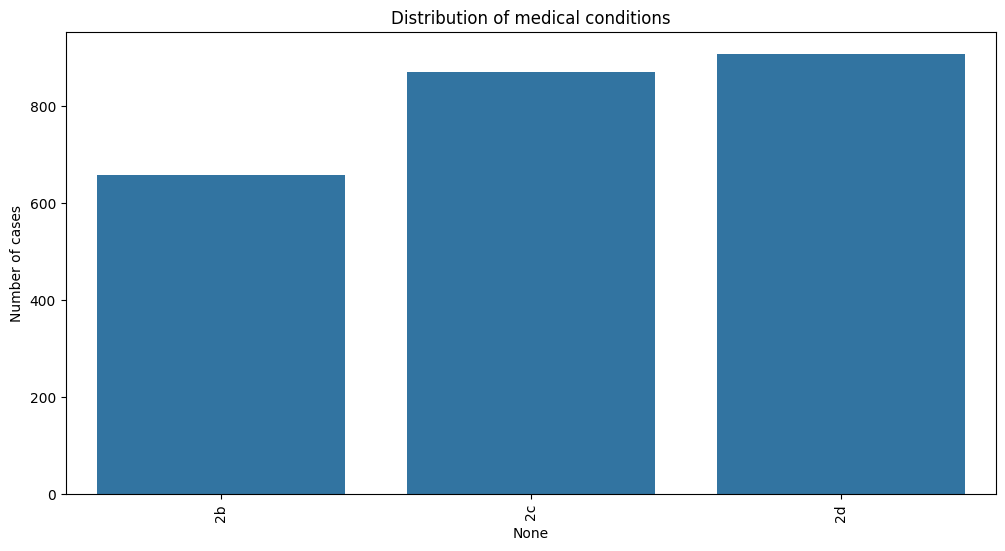

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(x=category_df.index, y=category_df['count'])
plt.xticks(rotation=90)
plt.ylabel("Number of cases")
plt.title("Distribution of medical conditions")
plt.show()

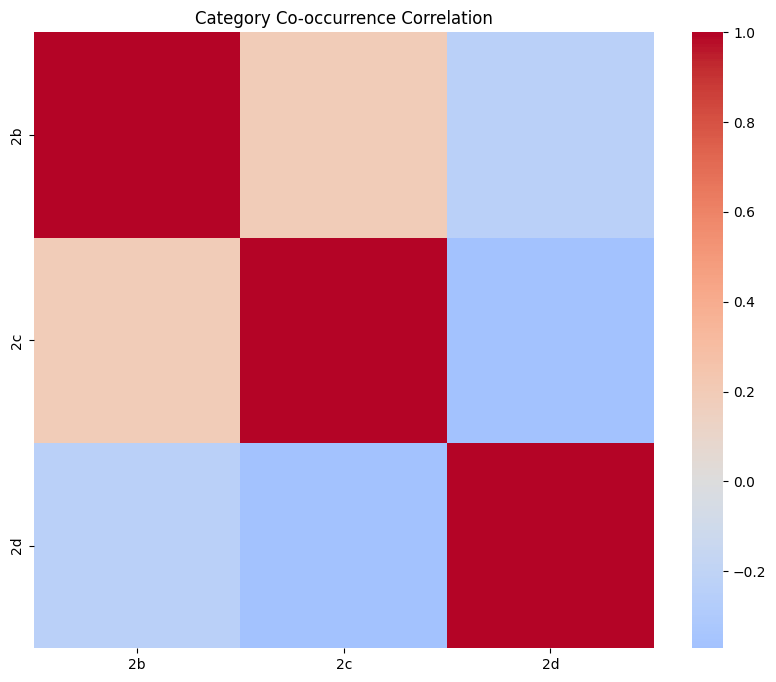

In [21]:
categories = sorted(set(
    cat for split in ["train", "val", "test"]
    for item in rex_data[split]
    for cat in item["categories"].values()
))

rows = []

for split in ["train", "val", "test"]:
    for item in rex_data[split]:
        cats = set(item["categories"].values())
        row = {cat: 1 if cat in cats else 0 for cat in categories}
        rows.append(row)

df = pd.DataFrame(rows)

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Category Co-occurrence Correlation")
plt.show()

In [22]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_pairs = upper.stack().reset_index()
corr_pairs.columns = ["cat1", "cat2", "corr"]

top5 = corr_pairs.sort_values(by="corr", ascending=False).head(5)

top5

,cat1,cat2,corr
1,2b,2c,0.189829
2,2b,2d,-0.237043
5,2c,2d,-0.371619
0,2b,2b,NaN
3,2c,2b,NaN


In [23]:
counts = {}

shortlisted_categories = {"2b", "2c", "2d"}

for split in ["train", "val", "test"]:
    count = 0
    for item in rex_data[split]:
        cats = set(item["categories"].values())
        if cats and cats.issubset(shortlisted_categories):
            count += 1
    counts[split] = count

print(counts)
print("total:", counts["train"] + counts["val"] + counts["test"])

{'train': 1354, 'val': 23, 'test': 41}
total: 1418


In [24]:
category_counts = Counter()

for split in ["train", "val", "test"]:
    for item in rex_data[split]:
        cats = item["categories"].values()
        cats_set = set(cats)
        
        # keep only scans fully inside shortlist
        if cats_set and cats_set.issubset(shortlisted_categories):
            category_counts.update(cats)

shortlisted_category_df = (
    pd.DataFrame.from_dict(category_counts, orient="index", columns=["count"])
    .sort_index()
)

shortlisted_category_df

,count
2b,659
2c,871
2d,908


In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

demo_ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_7150/train_7150_a/train_7150_a_2.nii.gz"
demo_segmentation_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/inference/train_7150_a_2/train_7150_a_2_class_2d_mask.nii.gz"

# Load data
ct_data = nib.load(demo_ct_path).get_fdata()
seg_data = nib.load(demo_segmentation_path).get_fdata()

print("CT shape:", ct_data.shape)
print("SEG shape:", seg_data.shape)

# Select a finding/channel
finding_idx = 0
seg_mask = seg_data[finding_idx]

print("Selected mask shape:", seg_mask.shape)

# Find slices containing the segmentation
seg_slices = np.where(seg_mask.sum(axis=(0, 1)) > 0)[0]

if len(seg_slices) == 0:
    raise ValueError("No segmentation found for this finding")

# Middle slice containing lesion
middle_slice = seg_slices[len(seg_slices) // 2]

# Plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(ct_data[:, :, middle_slice], cmap="gray")
plt.title("CT Scan")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ct_data[:, :, middle_slice], cmap="gray")
plt.imshow(seg_mask[:, :, middle_slice], cmap="Reds", alpha=0.5)
plt.title(f"Overlay - Finding {finding_idx}")
plt.axis("off")

plt.tight_layout()
plt.show()

CT shape: (512, 512, 489)
SEG shape: (220, 220, 244)
Selected mask shape: (220, 244)


ValueError: Calling nonzero on 0d arrays is not allowed. Use np.atleast_1d(scalar).nonzero() instead. If the context of this error is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.

CT shape: (512, 512, 238)
GT shape: (1, 512, 512, 238)
Heatmap shape: (216, 216, 198)
Selected slice: 77


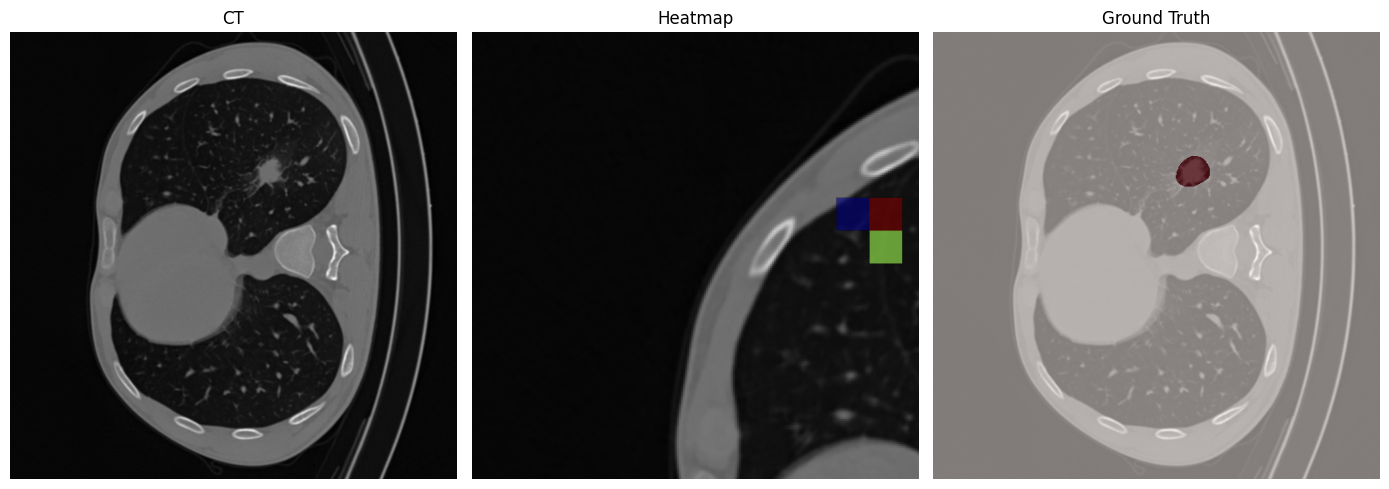

In [66]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1741/train_1741_b/train_1741_b_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_1741_b_2.nii.gz"

heatmap_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/heatmaps/train_1741_b_2_Consolidation_heatmap.nii.gz"

# ------------------------------------------------------------------
# Load data (NO RESAMPLING)
# ------------------------------------------------------------------

ct_data = nib.load(ct_path).get_fdata()
gt_data = nib.load(gt_path).get_fdata()
heatmap_data = nib.load(heatmap_path).get_fdata()

print("CT shape:", ct_data.shape)
print("GT shape:", gt_data.shape)
print("Heatmap shape:", heatmap_data.shape)

# ------------------------------------------------------------------
# Fix dimensions
# ------------------------------------------------------------------

# GT: remove channel dim if needed
if gt_data.ndim == 4:
    gt_mask = gt_data[0]
else:
    gt_mask = gt_data

# Heatmap: remove channel dim if needed
if heatmap_data.ndim == 4:
    heatmap = heatmap_data[..., 0]
else:
    heatmap = heatmap_data

# ------------------------------------------------------------------
# Find GT slices (same logic as your working code)
# ------------------------------------------------------------------

gt_slices = np.where(gt_mask.sum(axis=(0, 1)) > 0)[0]

if len(gt_slices) == 0:
    raise ValueError("No GT found")

middle_slice = gt_slices[len(gt_slices) // 2]

print("Selected slice:", middle_slice)

# ------------------------------------------------------------------
# Extract slices
# ------------------------------------------------------------------

ct_slice = ct_data[:, :, middle_slice]
gt_slice = gt_mask[:, :, middle_slice]
heatmap_slice = heatmap[:, :, middle_slice]

# ------------------------------------------------------------------
# Threshold heatmap (optional)
# ------------------------------------------------------------------

threshold = np.percentile(np.abs(heatmap), 99)

heatmap_masked = np.where(
    np.abs(heatmap_slice) > threshold,
    heatmap_slice,
    np.nan
)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

plt.figure(figsize=(14, 6))

# CT
plt.subplot(1, 3, 1)
plt.imshow(ct_slice, cmap="gray")
plt.title("CT")
plt.axis("off")

# Heatmap
plt.subplot(1, 3, 2)
plt.imshow(ct_slice, cmap="gray")
plt.imshow(heatmap_masked, cmap="jet", alpha=0.6)
plt.title("Heatmap")
plt.axis("off")

# GT (THIS WILL NOW WORK)
plt.subplot(1, 3, 3)
plt.imshow(ct_slice, cmap="gray")
plt.imshow(gt_slice, cmap="Reds", alpha=0.5)
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
print("GT total voxels:", gt_mask.sum())
print("GT slices with signal:", np.where(gt_mask.sum(axis=(0,1)) > 0)[0][:20])

GT total voxels: 1651.0
GT slices with signal: [277 278 279 280 379 380 381 382 383 384 393 394 395 396 397]


In [ ]:
print("Original seg min/max:", seg_nii.get_fdata().min(), seg_nii.get_fdata().max())
print("Resampled seg min/max:", seg_data.min(), seg_data.max())

Original seg min/max: -0.034936897456645966 0.04412262514233589
Resampled seg min/max: -0.03381255269050598 0.022882752120494843


In [ ]:
# find the dimensions of the scans in the shortlisted categories
scan_dimensions = []

for split in ["train"]:
    for item in rex_data[split][:100]:
        print(f"checking scan: {item['name']}")

        cats = set(item["categories"].values())

        if cats and cats.issubset(shortlisted_categories):
            scan_name = item["name"]

            matches = list(
                data_volumes_folder_path.rglob(scan_name)
            )

            if matches:
                scan = nib.load(matches[0])
                scan_dimensions.append(scan.shape)

print(scan_dimensions[:5])
print(len(scan_dimensions))

checking scan: train_1741_b_2.nii.gz
checking scan: train_1591_f_2.nii.gz
checking scan: train_1741_c_2.nii.gz
checking scan: train_2239_a_2.nii.gz
checking scan: train_1591_c_2.nii.gz
checking scan: train_1785_a_2.nii.gz
checking scan: train_1959_b_2.nii.gz
checking scan: train_1661_b_1.nii.gz
checking scan: train_1676_a_2.nii.gz
checking scan: train_1544_a_1.nii.gz
checking scan: train_2256_a_2.nii.gz
checking scan: train_2394_a_1.nii.gz
checking scan: train_2226_a_1.nii.gz
checking scan: train_1296_a_2.nii.gz
checking scan: train_1349_a_2.nii.gz
checking scan: train_1696_a_2.nii.gz
checking scan: train_2381_a_2.nii.gz
checking scan: train_1606_a_2.nii.gz
checking scan: train_1860_a_1.nii.gz
checking scan: train_1427_a_2.nii.gz
checking scan: train_2111_a_1.nii.gz
checking scan: train_1850_a_1.nii.gz
checking scan: train_1441_a_2.nii.gz
checking scan: train_1823_a_2.nii.gz
checking scan: train_2039_a_2.nii.gz
checking scan: train_1580_a_2.nii.gz
checking scan: train_2347_a_1.nii.gz
c

In [ ]:
print(scan.shape)
print(scan.header.get_zooms())

(512, 512, 220)
(np.float32(0.7402344), np.float32(0.7402344), np.float32(1.5))


In [ ]:
# find the number of patches per category in the shortlisted categories
# A patch is 32x32x32 voxels. 
# segmentations_folder_path gives the segmentation masks for each scan. We can use these masks to count the number of patches that contain each category.

patch_size = 32
patch_df = pd.DataFrame(columns=["scan_name", "finding", "category", "patch_count"])

def pad_to_multiple(arr, m=32):
    pad = [(0, (m - s % m) % m) for s in arr.shape]
    return np.pad(arr, pad, mode="constant", constant_values=0)


def count_patches_3d(mask3d, patch_size=32):
    mask3d = pad_to_multiple(mask3d, patch_size)

    sx, sy, sz = mask3d.shape

    patches = mask3d.reshape(
        sx // patch_size, patch_size,
        sy // patch_size, patch_size,
        sz // patch_size, patch_size
    )

    patches = patches.transpose(0, 2, 4, 1, 3, 5)
    patches = patches.reshape(-1, patch_size, patch_size, patch_size)

    return np.sum(np.any(patches, axis=(1, 2, 3)))


for split in ["train"][:10]:
    for item in rex_data[split]:

        scan_name = item["name"]
        categories = item["categories"]

        print(f"\nchecking scan: {scan_name}")

        seg_matches = list(Path(segmentations_folder_path).rglob(scan_name))
        if not seg_matches:
            continue

        seg = nib.load(seg_matches[0]).get_fdata()

        print("seg shape:", seg.shape)

        # seg is (F, H, W, D)
        F = seg.shape[0]

        for f in range(F):

            cat = categories.get(str(f), None)

            if cat is None:
                continue

            if cat not in shortlisted_categories:
                continue

            mask3d = seg[f]

            # treat each finding as foreground mask
            mask3d = (mask3d > 0).astype(np.uint8)

            patch_count = count_patches_3d(mask3d, patch_size)

            print(f"Scan: {scan_name}, Finding: {f}, Category: {cat}, Patches: {patch_count}")

            patch_df = pd.concat(
                [
                    patch_df,
                    pd.DataFrame([{
                        "scan_name": scan_name,
                        "finding": f,
                        "category": cat,
                        "patch_count": patch_count
                    }])
                ],
                ignore_index=True
            )


checking scan: train_1741_b_2.nii.gz
seg shape: (1, 512, 512, 238)
Scan: train_1741_b_2.nii.gz, Finding: 0, Category: 2b, Patches: 6

checking scan: train_1591_f_2.nii.gz
seg shape: (5, 512, 512, 466)
Scan: train_1591_f_2.nii.gz, Finding: 0, Category: 2b, Patches: 22
Scan: train_1591_f_2.nii.gz, Finding: 1, Category: 2b, Patches: 14
Scan: train_1591_f_2.nii.gz, Finding: 2, Category: 2b, Patches: 4
Scan: train_1591_f_2.nii.gz, Finding: 3, Category: 2b, Patches: 14
Scan: train_1591_f_2.nii.gz, Finding: 4, Category: 2b, Patches: 13

checking scan: train_1741_c_2.nii.gz
seg shape: (2, 512, 512, 247)
Scan: train_1741_c_2.nii.gz, Finding: 0, Category: 2b, Patches: 16
Scan: train_1741_c_2.nii.gz, Finding: 1, Category: 2d, Patches: 3

checking scan: train_2239_a_2.nii.gz
seg shape: (1, 512, 512, 412)
Scan: train_2239_a_2.nii.gz, Finding: 0, Category: 2c, Patches: 62

checking scan: train_1591_c_2.nii.gz
seg shape: (6, 512, 512, 463)
Scan: train_1591_c_2.nii.gz, Finding: 0, Category: 2b, Patch

KeyboardInterrupt: 

In [ ]:
patch_df

,scan_name,finding,category,patch_count
0,train_1741_b_2.nii.gz,0,2b,6
1,train_1591_f_2.nii.gz,0,2b,22
2,train_1591_f_2.nii.gz,1,2b,14
3,train_1591_f_2.nii.gz,2,2b,4
4,train_1591_f_2.nii.gz,3,2b,14
...,...,...,...,...
2331,train_929_a_1.nii.gz,0,2c,53
2332,valid_915_b_2.nii.gz,0,2d,1
2333,valid_915_b_2.nii.gz,1,2d,2
2334,train_1053_a_1.nii.gz,0,2c,25


In [ ]:
# # create csv from patch_df
# patch_df.to_csv("/home/chest_ct/code/models/patch_counts.csv", index=False)

In [ ]:
total_patches_per_category = (
    patch_df.groupby("category")["patch_count"]
    .sum()
    .reset_index()
)

print(total_patches_per_category)

  category patch_count
0       2b       16392
1       2c       20371
2       2d        4011


In [ ]:
# patch_size = 32

# from collections import defaultdict

# category_patch_counts = defaultdict(int)

# def pad_to_multiple(arr, m=32):
#     pad = [(0, (m - s % m) % m) for s in arr.shape]
#     return np.pad(arr, pad, mode="constant", constant_values=0)


# def count_patches_3d(mask3d, patch_size=32):
#     mask3d = pad_to_multiple(mask3d, patch_size)

#     sx, sy, sz = mask3d.shape

#     patches = mask3d.reshape(
#         sx // patch_size, patch_size,
#         sy // patch_size, patch_size,
#         sz // patch_size, patch_size
#     )

#     patches = patches.transpose(0, 2, 4, 1, 3, 5)
#     patches = patches.reshape(-1, patch_size, patch_size, patch_size)

#     return np.sum(np.any(patches, axis=(1, 2, 3)))


# for split in ["train"]:
#     for item in rex_data[split][:10]:

#         scan_name = item["name"]
#         cats = set(item["categories"].values())

#         print(f"\nchecking scan: {scan_name}")

#         seg_matches = list(Path(segmentations_folder_path).rglob(scan_name))
#         if not seg_matches:
#             continue

#         seg = nib.load(seg_matches[0]).get_fdata()

#         # seg shape: (F, H, W, D)
#         print("seg shape:", seg.shape)

#         findings, H, W, D = seg.shape

#         for f in range(findings):
#             mask3d = seg[f]

#             # binary mask per finding
#             mask3d = (mask3d > 0).astype(np.uint8)

#             patch_count = count_patches_3d(mask3d, patch_size)

#             category = item["categories"][str(f)]
#             category_patch_counts[category] += patch_count

# for cat, total_patches in category_patch_counts.items():
#     print(cat, total_patches)

In [ ]:
# # Add CT-RATE normal scans into RexGroundingCT metadata (train split)
# dataset_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_new.json"

# # `normal_scans` was created above as a filtered DataFrame; extract VolumeName list
# normal_scan_names = normal_scans["VolumeName"].astype(str).tolist()

# with open(dataset_path, "r") as f:
#     metadata = json.load(f)

# # Ensure expected split exists
# if "train" not in metadata or not isinstance(metadata["train"], list):
#     metadata["train"] = []

# # Avoid duplicates by existing scan name
# existing_names = {item.get("name", "") for item in metadata["train"] if isinstance(item, dict)}

# new_entries = []
# for scan_name in normal_scan_names:
#     name = scan_name if scan_name.endswith(".nii.gz") else f"{scan_name}.nii.gz"
#     if name in existing_names:
#         continue

#     new_entries.append({
#         "name": name,
#         "findings": {},
#         "entity_counts": {},
#         "pixels": {},
#         "categories": {},
#         "shape": [512, 512, 264],
#         "protocol": "protocol1",
#     })

# metadata["train"].extend(new_entries)

# with open(dataset_path, "w") as f:
#     json.dump(metadata, f, indent=2)

# print(f"Added {len(new_entries)} normal scans to train split in {dataset_path}")
# print(f"Train split total: {len(metadata['train'])}")

## LC-KSVD localization

# LOGS


In [2]:

hest_ct@blackbox-Z790-EAGLE-AX:~/code$  source /home/chest_ct/code/.venv/bin/activate
(.venv) chest_ct@blackbox-Z790-EAGLE-AX:~/code$ uv add cupy-cuda132
error: No `pyproject.toml` found in current directory or any parent directory
(.venv) chest_ct@blackbox-Z790-EAGLE-AX:~/code$ cd models/lc-ksvd/
(.venv) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd$ source .venv/bin/activate
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd$ uv add cupy-cuda132
  × No solution found when resolving dependencies for split (markers: python_full_version >= '3.14' and sys_platform == 'win32'):
  ╰─▶ Because cupy-cuda132 was not found in the package registry and your project depends on cupy-cuda132, we can conclude that your project's requirements are unsatisfiable.

      hint: While the active Python version is 3.12, the resolution failed for other Python versions supported by your project. Consider limiting your project's supported Python
      versions using `requires-python`.
  help: If you want to add the package regardless of the failed resolution, provide the `--frozen` flag to skip locking and syncing.
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd$ uv add cupy-cuda13x
Resolved 24 packages in 4.29s
      Built lc-ksvd @ file:///home/chest_ct/code/models/lc-ksvd
Prepared 2 packages in 43.02s
Uninstalled 1 package in 0.82ms
Installed 3 packages in 23ms
 + cuda-pathfinder==1.5.4
 + cupy-cuda13x==14.1.0
 ~ lc-ksvd==0.1.0 (from file:///home/chest_ct/code/models/lc-ksvd)
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd$ uv pip install reppi==0.1.3
Resolved 5 packages in 2.22s
Prepared 1 package in 462ms
Uninstalled 1 package in 0.67ms
Installed 1 package in 2ms
 - reppi==0.1.0
 + reppi==0.1.3
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd$ uv add reppi==0.1.3
Resolved 24 packages in 1.61s
      Built lc-ksvd @ file:///home/chest_ct/code/models/lc-ksvd
Prepared 1 package in 884ms
Uninstalled 1 package in 0.25ms
Installed 1 package in 0.26ms
 ~ lc-ksvd==0.1.0 (from file:///home/chest_ct/code/models/lc-ksvd)
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd$ git pull origin develop
remote: Enumerating objects: 263, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 263 (delta 76), reused 95 (delta 64), pack-reused 151 (from 1)
Receiving objects: 100% (263/263), 20.17 MiB | 722.00 KiB/s, done.
Resolving deltas: 100% (149/149), completed with 26 local objects.
From github.com:ckekula/fyp-3d-ct
 * branch            develop    -> FETCH_HEAD
   78b9028..152efbe  develop    -> origin/develop
Updating 78b9028..152efbe
Fast-forward
 AUROC_ISSUES_FOUND.md                                                                             |   187 +
 documents/Progress Report/Chapters/ch_1.tex                                                       |   162 +-
 documents/Progress Report/Chapters/ch_2.tex                                                       |   160 +-
 documents/Progress Report/Chapters/ch_3.tex                                                       |   193 +-
 documents/Progress Report/Chapters/ch_4.tex                                                       |   247 +-
 documents/Progress Report/Chapters/ch_5.tex                                                       |    28 +-
 documents/Progress Report/Chapters/ch_6.tex                                                       |    11 +-
 documents/Progress Report/Chapters/ch_7.tex                                                       |    12 +
 documents/Progress Report/Chapters/ch_test.tex                                                    |    29 +-
 documents/Progress Report/Chapters/chapter1PIC/2D to 3D.jpg                                       |   Bin 0 -> 55883 bytes
 documents/Progress Report/Chapters/chapter1PIC/4 pathologies.jpg                                  |   Bin 0 -> 47420 bytes
 documents/Progress Report/Chapters/chapter1PIC/HIresCAM.jpg                                       |   Bin 0 -> 37440 bytes
 documents/Progress Report/Chapters/chapter1PIC/Preprocessing.jpg                                  |   Bin 0 -> 53903 bytes
 documents/Progress Report/Chapters/chapter1PIC/Timeline.jpg                                       |   Bin 0 -> 28228 bytes
 documents/Progress Report/Chapters/chapter1PIC/training.jpg                                       |   Bin 0 -> 46873 bytes
 documents/Progress Report/Front_matters/abstract.tex                                              |    19 +-
 documents/Progress Report/Front_matters/acknowledgements.tex                                      |    15 +-
 documents/Progress Report/Front_matters/acronyms.tex                                              |    29 +-
 documents/Progress Report/Front_matters/cover.tex                                                 |    15 +-
 documents/Progress Report/Front_matters/preface.tex                                               |     6 +-
 documents/Progress Report/Images/Chapter 4/Evaluation_FrameWork_Architecture_Diagram.png          |   Bin 0 -> 983501 bytes
 documents/Progress Report/Images/Chapter 4/LC-KSVD_Visualization_Result.png                       |   Bin 0 -> 222607 bytes
 documents/Progress Report/Images/Chapter 4/Localization_Dice_Comparison_BiomedParse_vs_Merlin.png |   Bin 0 -> 186028 bytes
 documents/Progress Report/Images/Chapter 4/Localization_Overall_Model_Comparison.png              |   Bin 0 -> 283871 bytes
 documents/Progress Report/Images/Chapter 4/Localization_PerClass_Model_Comparison.png             |   Bin 0 -> 324339 bytes
 documents/Progress Report/Images/Chapter 4/Methodology_Diagram.png                                |   Bin 0 -> 1039081 bytes
 documents/Progress Report/Images/Chapter 4/classification_behavior_profile.png                    |   Bin 0 -> 147662 bytes
 documents/Progress Report/Images/Chapter 4/classification_macro_comparison.png                    |   Bin 0 -> 1433609 bytes
 documents/Progress Report/Images/Chapter 4/classification_per_class_auroc.png                     |   Bin 0 -> 202265 bytes
 documents/Progress Report/Images/Chapter 4/train_272_a_2_gt_pred_comparison.png                   |   Bin 0 -> 1065893 bytes
 documents/Progress Report/Images/Chapter 4/train_66_a_2_gt_pred_comparison_lung_nodule.png        |   Bin 0 -> 854770 bytes
 documents/Progress Report/Report.pdf                                                              | 33385 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++---------------
 documents/Progress Report/Report.tex                                                              |    29 +-
 documents/Progress Report/bibliography.bib                                                        |   150 +-
 documents/Progress Report/pagesetup.cfg                                                           |     5 +-
 eval/adapters/biomedparse_adapter.py                                                              |   154 +-
 eval/adapters/ctclip_adapter.py                                                                   |   118 +-
 eval/adapters/merlin_adapter.py                                                                   |    25 +-
 eval/generate_evaluation_figures.py                                                               |    22 +-
 eval/outputs/classification/biomed_parse_rexgroundingct_classification_metrics.csv                |     6 +
 eval/outputs/classification/biomed_parse_rexgroundingct_classification_metrics.json               |    64 +
 eval/outputs/classification/ct_clip_lipro_classification_metrics.csv                              |     6 +
 eval/outputs/classification/ct_clip_lipro_classification_metrics.json                             |    64 +
 eval/outputs/classification/ct_clip_zero_shot_classification_metrics.csv                          |     6 -
 eval/outputs/classification/ct_clip_zero_shot_classification_metrics.json                         |    64 -
 eval/outputs/comparison/model_comparison_summary.json                                             |   211 +
 eval/runners/evaluate_classification.py                                                           |    13 +-
 models/ct-clip/results_lipro_inference/aurocs.xlsx                                                |   Bin 5387 -> 6361 bytes
 models/lc-ksvd/README.md                                                                          |   113 +
 models/lc-ksvd/src/lc_ksvd/config.py                                                              |     2 +-
 models/lc-ksvd/src/lc_ksvd/patch_extractor.py                                                     |   302 +-
 models/lc-ksvd/src/lc_ksvd/train.py                                                               |   125 +-
 outputs/biomedparse_rexgroundingct_cpu/train_272_a_2_gt_pred_comparison.png                       |   Bin 0 -> 1325741 bytes
 outputs/biomedparse_rexgroundingct_cpu/train_272_a_2_gt_vs_pred_overlay.png                       |   Bin 1314677 -> 0 bytes
 scripts/remove_hyphens.ps1                                                                        |    14 +
 55 files changed, 28517 insertions(+), 7474 deletions(-)
 create mode 100644 AUROC_ISSUES_FOUND.md
 create mode 100644 documents/Progress Report/Chapters/ch_7.tex
 create mode 100644 documents/Progress Report/Chapters/chapter1PIC/2D to 3D.jpg
 create mode 100644 documents/Progress Report/Chapters/chapter1PIC/4 pathologies.jpg
 create mode 100644 documents/Progress Report/Chapters/chapter1PIC/HIresCAM.jpg
 create mode 100644 documents/Progress Report/Chapters/chapter1PIC/Preprocessing.jpg
 create mode 100644 documents/Progress Report/Chapters/chapter1PIC/Timeline.jpg
 create mode 100644 documents/Progress Report/Chapters/chapter1PIC/training.jpg
 create mode 100644 documents/Progress Report/Images/Chapter 4/Evaluation_FrameWork_Architecture_Diagram.png
 create mode 100644 documents/Progress Report/Images/Chapter 4/LC-KSVD_Visualization_Result.png
 create mode 100644 documents/Progress Report/Images/Chapter 4/Localization_Dice_Comparison_BiomedParse_vs_Merlin.png
 create mode 100644 documents/Progress Report/Images/Chapter 4/Localization_Overall_Model_Comparison.png
 create mode 100644 documents/Progress Report/Images/Chapter 4/Localization_PerClass_Model_Comparison.png
 create mode 100644 documents/Progress Report/Images/Chapter 4/Methodology_Diagram.png
 create mode 100644 documents/Progress Report/Images/Chapter 4/classification_behavior_profile.png
 create mode 100644 documents/Progress Report/Images/Chapter 4/classification_macro_comparison.png
 create mode 100644 documents/Progress Report/Images/Chapter 4/classification_per_class_auroc.png
 create mode 100644 documents/Progress Report/Images/Chapter 4/train_272_a_2_gt_pred_comparison.png
 create mode 100644 documents/Progress Report/Images/Chapter 4/train_66_a_2_gt_pred_comparison_lung_nodule.png
 create mode 100644 eval/outputs/classification/biomed_parse_rexgroundingct_classification_metrics.csv
 create mode 100644 eval/outputs/classification/biomed_parse_rexgroundingct_classification_metrics.json
 create mode 100644 eval/outputs/classification/ct_clip_lipro_classification_metrics.csv
 create mode 100644 eval/outputs/classification/ct_clip_lipro_classification_metrics.json
 delete mode 100644 eval/outputs/classification/ct_clip_zero_shot_classification_metrics.csv
 delete mode 100644 eval/outputs/classification/ct_clip_zero_shot_classification_metrics.json
 create mode 100644 eval/outputs/comparison/model_comparison_summary.json
 create mode 100644 outputs/biomedparse_rexgroundingct_cpu/train_272_a_2_gt_pred_comparison.png
 delete mode 100644 outputs/biomedparse_rexgroundingct_cpu/train_272_a_2_gt_vs_pred_overlay.png
 create mode 100644 scripts/remove_hyphens.ps1
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd$ python lc_ksvd.train
python: can't open file '/home/chest_ct/code/models/lc-ksvd/lc_ksvd.train': [Errno 2] No such file or directory
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd$ cd src
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd/src$ python lc_ksvd.train
python: can't open file '/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd.train': [Errno 2] No such file or directory
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd/src$ python lc_ksvd/train.py
INFO Running unified patch extraction (train + val)…
INFO LabelRegistry built split='train' total_volumes=1573 normal=219 per_category_counts={'normal': 0, '2b': 427, '2c': 640, '2d': 672}
INFO   category 2b: 427 volumes (sample: ['train_1741_b_2', 'train_1591_f_2', 'train_1741_c_2'])
INFO   category 2c: 640 volumes (sample: ['train_2239_a_2', 'train_1591_c_2', 'train_1785_a_2'])
INFO   category 2d: 672 volumes (sample: ['train_1741_c_2', 'train_1591_c_2', 'train_1959_b_2'])
INFO Raw positive IDs deduped: 1354 (sample: ['train_1157_e_2', 'train_12229_a_2', 'train_12344_a_1', 'train_6444_a_1', 'train_12317_a_2'])
INFO After path resolution: abnormal=938
INFO Raw normal IDs from metadata: 219, e.g. ['train_12342_a_1', 'train_10990_a_1', 'train_9664_a_1']
INFO Split=train | abnormal=938 | normal=219
INFO Phase 1 — sampling 30 patches from each of 219 normal scans…
normal scans: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 219/219 [08:09<00:00,  2.23s/it]
INFO   → 6570 normal patches collected.
abnormal scans: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [42:51<00:00,  2.74s/it]
INFO   → 7543 patches for 2b (before upsampling)
INFO   → 9865 patches for 2c (before upsampling)
INFO   → 10732 patches for 2d (before upsampling)
INFO Upsampling to 10732 patches per class. Before: {0: 6570, 1: 7543, 2: 9865, 3: 10732}
INFO After upsampling: {0: 10732, 1: 10732, 2: 10732, 3: 10732}
INFO Final matrix: X=(32768, 42928), H=(42928,), scan_ids=(42928,)
INFO Saved → outputs/patches/unified_train.npz  (X: (32768, 42928), H: (42928,))
INFO LabelRegistry built split='val' total_volumes=87 normal=64 per_category_counts={'normal': 0, '2b': 7, '2c': 11, '2d': 12}
INFO   category 2b: 7 volumes (sample: ['train_13591_a_1', 'train_13035_a_1', 'train_13256_b_2'])
INFO   category 2c: 11 volumes (sample: ['train_13591_a_1', 'train_13256_b_2', 'train_13141_a_1'])
INFO   category 2d: 12 volumes (sample: ['train_13035_a_1', 'train_13301_a_2', 'train_13113_a_1'])
INFO Raw positive IDs deduped: 23 (sample: ['train_13572_a_2', 'train_13447_a_1', 'train_13075_a_2', 'train_13113_a_1', 'train_13148_a_2'])
INFO After path resolution: abnormal=10
INFO Raw normal IDs from metadata: 64, e.g. ['train_11880_a_5', 'train_4462_a_1', 'train_5233_a_1']
INFO Split=val | abnormal=10 | normal=64
INFO Phase 1 — sampling 30 patches from each of 64 normal scans…
normal scans: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [02:11<00:00,  2.06s/it]
INFO   → 1920 normal patches collected.
abnormal scans: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:23<00:00,  2.36s/it]
INFO   → 112 patches for 2b (before upsampling)
INFO   → 128 patches for 2c (before upsampling)
INFO   → 60 patches for 2d (before upsampling)
INFO Upsampling to 1920 patches per class. Before: {0: 1920, 1: 112, 2: 128, 3: 60}
INFO After upsampling: {0: 1920, 1: 1920, 2: 1920, 3: 1920}
INFO Final matrix: X=(32768, 7680), H=(7680,), scan_ids=(7680,)
INFO Saved → outputs/patches/unified_val.npz  (X: (32768, 7680), H: (7680,))
INFO 
============================================================
Training unified LC-KSVD2 model
============================================================
INFO Train — X: (32768, 42928), H: (42928,)
INFO   train (raw) class normal: 10732 patches
INFO   train (raw) class 2b: 10732 patches
INFO   train (raw) class 2c: 10732 patches
INFO   train (raw) class 2d: 10732 patches
INFO Dropped 11 zero-norm patches; 42917 remaining.
INFO   train (after zero-norm drop) class normal: 10721 patches
INFO   train (after zero-norm drop) class 2b: 10732 patches
INFO   train (after zero-norm drop) class 2c: 10732 patches
INFO   train (after zero-norm drop) class 2d: 10732 patches
INFO Val: dropped 4 zero-norm patches; 7676 remaining.
INFO   val (after zero-norm drop) class normal: 1916 patches
INFO   val (after zero-norm drop) class 2b: 1920 patches
INFO   val (after zero-norm drop) class 2c: 1920 patches
INFO   val (after zero-norm drop) class 2d: 1920 patches
INFO Starting LC-KSVD2 training…
Running initialisation K-SVD...
Traceback (most recent call last):
  File "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/train.py", line 261, in <module>
    main()
  File "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/train.py", line 250, in main
    result = train()
             ^^^^^^^
  File "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/train.py", line 202, in train
    model.fit(X_norm, H_onehot)
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/dictionary/lc_ksvd.py", line 354, in fit
    D_init, A_init, W_init, Q = initialization4lcksvd(
                                ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/dictionary/lc_ksvd.py", line 175, in initialization4lcksvd
    ksvd.fit(X)
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/dictionary/ksvd.py", line 105, in fit
    D = self._init_dict(X, D_init, rng)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/dictionary/ksvd.py", line 165, in _init_dict
    chosen = rng.choice(valid, size=k, replace=False)
             ^^^^^^^^^^
AttributeError: 'Generator' object has no attribute 'choice'
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd/src$ python lc_ksvd/train.py --skip-extraction
INFO 
============================================================
Training unified LC-KSVD2 model
============================================================
INFO Train — X: (32768, 42928), H: (42928,)
INFO   train (raw) class normal: 10732 patches
INFO   train (raw) class 2b: 10732 patches
INFO   train (raw) class 2c: 10732 patches
INFO   train (raw) class 2d: 10732 patches
INFO Dropped 11 zero-norm patches; 42917 remaining.
INFO   train (after zero-norm drop) class normal: 10721 patches
INFO   train (after zero-norm drop) class 2b: 10732 patches
INFO   train (after zero-norm drop) class 2c: 10732 patches
INFO   train (after zero-norm drop) class 2d: 10732 patches
INFO Val: dropped 4 zero-norm patches; 7676 remaining.
INFO   val (after zero-norm drop) class normal: 1916 patches
INFO   val (after zero-norm drop) class 2b: 1920 patches
INFO   val (after zero-norm drop) class 2c: 1920 patches
INFO   val (after zero-norm drop) class 2d: 1920 patches
INFO Starting LC-KSVD2 training…
Running initialisation K-SVD...
Traceback (most recent call last):
  File "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/train.py", line 261, in <module>
    main()
  File "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/train.py", line 250, in main
    result = train()
             ^^^^^^^
  File "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/train.py", line 202, in train
    model.fit(X_norm, H_onehot)
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/dictionary/lc_ksvd.py", line 354, in fit
    D_init, A_init, W_init, Q = initialization4lcksvd(
                                ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/dictionary/lc_ksvd.py", line 175, in initialization4lcksvd
    ksvd.fit(X)
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/dictionary/ksvd.py", line 110, in fit
    Gamma = self._sparse_code(X, D, G)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/dictionary/ksvd.py", line 179, in _sparse_code
    return coder.encode(X, D, G=G)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/sparse/omp.py", line 209, in encode
    return batch_omp(DtX, G, T)
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/sparse/omp.py", line 132, in batch_omp
    c = linalg.cho_solve((L[: k + 1, : k + 1], True), rhs)
        ^^^^^^^^^^^^^^^^
AttributeError: module 'cupyx.scipy.linalg' has no attribute 'cho_solve'. Did you mean: 'lu_solve'?
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd/src$ python lc_ksvd/train.py --skip-extraction
INFO 
============================================================
Training unified LC-KSVD2 model
============================================================
INFO Train — X: (32768, 42928), H: (42928,)
INFO   train (raw) class normal: 10732 patches
INFO   train (raw) class 2b: 10732 patches
INFO   train (raw) class 2c: 10732 patches
INFO   train (raw) class 2d: 10732 patches
INFO Dropped 11 zero-norm patches; 42917 remaining.
INFO   train (after zero-norm drop) class normal: 10721 patches
INFO   train (after zero-norm drop) class 2b: 10732 patches
INFO   train (after zero-norm drop) class 2c: 10732 patches
INFO   train (after zero-norm drop) class 2d: 10732 patches
INFO Val: dropped 4 zero-norm patches; 7676 remaining.
INFO   val (after zero-norm drop) class normal: 1916 patches
INFO   val (after zero-norm drop) class 2b: 1920 patches
INFO   val (after zero-norm drop) class 2c: 1920 patches
INFO   val (after zero-norm drop) class 2d: 1920 patches
INFO Starting LC-KSVD2 training…
Running initialisation K-SVD...
Iter 1/20  RMSE=0.001930
Iter 2/20  RMSE=0.001866
Iter 3/20  RMSE=0.001851
Iter 4/20  RMSE=0.001845
Iter 5/20  RMSE=0.001840
Iter 6/20  RMSE=0.001837
Iter 7/20  RMSE=0.001835
Iter 8/20  RMSE=0.001833
Iter 9/20  RMSE=0.001832
Iter 10/20  RMSE=0.001830
Iter 11/20  RMSE=0.001829
Iter 12/20  RMSE=0.001828
Iter 13/20  RMSE=0.001827
Iter 14/20  RMSE=0.001826
Iter 15/20  RMSE=0.001825
Iter 16/20  RMSE=0.001825
Iter 17/20  RMSE=0.001825
Iter 18/20  RMSE=0.001825
Iter 19/20  RMSE=0.001825
Iter 20/20  RMSE=0.001825
Traceback (most recent call last):
  File "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/train.py", line 261, in <module>
    main()
  File "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/train.py", line 250, in main
    result = train()
             ^^^^^^^
  File "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/train.py", line 202, in train
    model.fit(X_norm, H_onehot)
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/dictionary/lc_ksvd.py", line 398, in fit
    D_aug_norm[:, j], gamma_j, idx, unused, replaced = _optimize_atom(
                                                       ^^^^^^^^^^^^^^^
  File "/home/chest_ct/code/models/lc-ksvd/.venv/lib/python3.12/site-packages/reppi/dictionary/ksvd.py", line 235, in _optimize_atom
    E = X[:, data_indices] - D @ small_gamma + xp.outer(D[:, j], g_j)
                             ~~^~~~~~~~~~~~~
  File "cupy/_core/core.pyx", line 1574, in cupy._core.core._ndarray_base.__matmul__
  File "cupy/_core/_routines_linalg.pyx", line 858, in cupy._core._routines_linalg.matmul
  File "cupy/_core/_routines_linalg.pyx", line 538, in cupy._core._routines_linalg.dot
  File "cupy/_core/_routines_linalg.pyx", line 602, in cupy._core._routines_linalg.tensordot_core
  File "cupy/_core/core.pyx", line 3250, in cupy._core.core._ndarray_init
  File "cupy/_core/core.pyx", line 300, in cupy._core.core._ndarray_base._init_fast
  File "cupy/cuda/memory.pyx", line 904, in cupy.cuda.memory.alloc
  File "cupy/cuda/memory.pyx", line 1614, in cupy.cuda.memory.MemoryPool.malloc
  File "cupy/cuda/memory.pyx", line 1635, in cupy.cuda.memory.MemoryPool.malloc
  File "cupy/cuda/memory.pyx", line 1350, in cupy.cuda.memory.SingleDeviceMemoryPool.malloc
  File "cupy/cuda/memory.pyx", line 1376, in cupy.cuda.memory.SingleDeviceMemoryPool._malloc
  File "cupy/cuda/memory.pyx", line 1560, in cupy.cuda.memory.SingleDeviceMemoryPool._try_malloc
cupy.cuda.memory.OutOfMemoryError: Out of memory allocating 5,894,890,496 bytes (allocated so far: 28,967,100,928 bytes).
(lc-ksvd) chest_ct@blackbox-Z790-EAGLE-AX:~/code/models/lc-ksvd/src$ 


SyntaxError: invalid character '×' (U+00D7) (2045243306.py, line 7)